# Assignment 2 : MovieLens Data Analysis using Apache Spark and Cassandra

## Data Management Assignment (2)

### Course Coordinator :
Dr. Bernard Lee Kok Bang
### Faculty :
FST UKM
### Subject : 
STQD6324 Sem 2/2025-2026
### Student:
Mohamad Sahfri bin Ab. Aziz (P146220)

# 📘 Data Management Assignment


```text
📘 Data Management Assignment
│
├── Introduction
├── Objectives
├── Technical Requirements
├── Environment Setup
│
├── Import Libraries
├── Spark Session
├── Load MovieLens Dataset
├── Create RDDs
├── Convert to DataFrames
├── Data Cleaning
├── Join DataFrames
│
├── Spark SQL Analysis
│     ├── Question (i)
│     ├── Question (ii)
│     ├── Question (iii)
│     ├── Question (iv)
│     └── Question (v)
│
├── Cassandra Integration
├── Read from Cassandra
├── Data Visualizations
├── Discussion
├── Conclusion
└── References
```

# 1. Introduction

The rapid growth of digital data has created significant challenges in storing, processing, and analysing large-scale datasets using traditional database management systems. Big Data technologies such as Apache Spark and Apache Cassandra provide scalable and efficient solutions for handling high-volume, high-velocity, and high-variety data. Apache Spark is an open-source distributed computing framework that enables fast in-memory data processing, while Apache Cassandra is a highly scalable NoSQL distributed database designed for high availability and fault tolerance.

This assignment demonstrates the application of Apache Spark and Apache Cassandra using the MovieLens 100K dataset. The dataset consists of movie ratings, movie information, and user demographic data. Apache Spark is used to load, clean, transform, and analyse the data using both Resilient Distributed Datasets (RDDs) and Spark DataFrames. Spark SQL is then applied to answer analytical questions related to movie ratings and user behaviour.

The processed data are subsequently integrated with Apache Cassandra to demonstrate distributed data storage and retrieval. The assignment also presents data visualizations and discussions to interpret the analytical findings.

This notebook follows a complete Big Data processing workflow from data ingestion to distributed analytics and NoSQL data storage.

# 2. Objectives

The objectives of this assignment are:

+ To understand the architecture and capabilities of Apache Spark and Apache Cassandra for Big Data processing.
+ To load and parse the MovieLens dataset into Apache Spark.
+ To create Resilient Distributed Datasets (RDDs) and transform them into Spark DataFrames.
+ To perform data cleaning and preprocessing before analysis.
+ To perform analytical queries using Apache Spark SQL.
+ To identify useful insights from movie ratings and user demographic information.
+ To demonstrate the integration of Apache Spark with Apache Cassandra for distributed data storage.
+ To visualize analytical results using appropriate charts and graphs.
+ To interpret the analytical findings and discuss their significance.
+ To demonstrate an end-to-end Big Data analytics workflow using distributed computing technologies.

# 3. Technical Requirement & Environment Setup

### Software Environment
|     Component	                         |         Version                 |
|----------------------------------------|---------------------------------|
| Operating System	                     | Ubuntu Linux (Docker Container) |
| Apache Spark	2.3.0.2.6.5.0-292        |                                 |
| Scala	                                 |    2.11.8                       |    | Java	                                 |  OpenJDK 1.8.0_171              |
| Apache Cassandra                       |	3.11.16                        |
| Python (Docker Notebook)               |	3.6                            |
| Python (HDP Sandbox)                   |	2.7.5                          |
| Jupyter Notebook	                     | Docker-based Notebook           |
| Hadoop Distribution	                 |Hortonworks Data Platform (HDP) 2.6.5|
| Dataset	                             | MovieLens 100K                  |

In [ ]:
import os

os.environ["PYSPARK_PYTHON"] = "/usr/bin/python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "/usr/bin/python3"

print("PYSPARK_PYTHON =", os.environ["PYSPARK_PYTHON"])

# 4. Python Libraries and Packages Used

In [113]:
from pyspark.sql import SparkSession
from pyspark.sql import Row
from pyspark.sql.functions import *
from pyspark.sql.types import *

import os
import glob
import shutil

import pandas as pd
import matplotlib.pyplot as plt

# 5. Library Description

|Library                   | 	Purpose                            |
|--------------------------|---------------------------------------|
| pyspark.sql              |	Create Spark DataFrames            |
| SparkSession	           | Initialize Apache Spark               |
| Row                      |	Create structured rows from RDDs   |
| pyspark.sql.functions    |	Data transformation and aggregation|
| pyspark.sql.types        |	Define DataFrame schemas           |
| os                       |	File and directory management      |
| glob                     |	Locate exported Spark files        |
| shutil                   |	Copy and organize exported files   |
| pandas	               |Convert Spark DataFrames for visualization|
|matplotlib                |	Generate charts and graphs         |

# 6. Spark Session Configuration


In [114]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens_Data_Management_Assignment") \
    .master("local[*]") \
    .getOrCreate()

sc = spark.sparkContext

### Spark Configuration

|Configuration	   | Value                              |
|------------------|------------------------------------|
| Application Name |	MovieLens_Data_Management_Assignment|
| Master           |	local[*]                            |
| Execution Mode   |	Local                               |
| Spark Version	   | 2.3.0.2.6.5.0-292                      |
| Python Interpreter|	/usr/bin/python3                    |
| Deployment Mode   |	Client                              |

In [ ]:
# Create Spark
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("MovieLens_Data_Management_Assignment") \
    .master("local[*]") \
    .config("spark.pyspark.python", "/usr/bin/python3") \
    .config("spark.pyspark.driver.python", "/usr/bin/python3") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

sc = spark.sparkContext

print("Spark version:", spark.version)
print("Spark master:", sc.master)
print("Spark Python executable:", sc.pythonExec)

# 7. Dataset Description & Load the datasets

The MovieLens 100K dataset contains 100,000 movie ratings collected from 943 users on 1,682 movies.

The dataset consists of three primary files:

|      File	         | Description        |
|--------------------|--------------------|
| u.data	         | User ratings for movies|
| u.item	         | Movie information and genres|
| u.user	         | User demographic information|

The dataset is loaded into Apache Spark, transformed into RDDs and DataFrames, cleaned, and analyzed using Spark SQL.

## a) u.data

In [3]:
# Test Python workers
test_rdd = sc.parallelize([1, 2, 3, 4, 5])

print("Values:", test_rdd.collect())
print("Count:", test_rdd.count())

Values: [1, 2, 3, 4, 5]
Count: 5


In [4]:
# Try the files
ratings_path = "/workspace/u.data"

ratings_raw_rdd = sc.textFile(ratings_path)

print("Number of ratings:", ratings_raw_rdd.count())
print("First five rows:", ratings_raw_rdd.take(5))

Number of ratings: 100000
First five rows: ['196\t242\t3\t881250949', '186\t302\t3\t891717742', '22\t377\t1\t878887116', '244\t51\t2\t880606923', '166\t346\t1\t886397596']


In [5]:
# Step 1: Parse the ratings RDD
def parse_rating(line):
    fields = line.split("\t")

    return (
        int(fields[0]),      # user_id
        int(fields[1]),      # movie_id
        float(fields[2]),    # rating
        int(fields[3])       # timestamp
    )

ratings_rdd = ratings_raw_rdd.map(parse_rating)

ratings_rdd.take(5)

[(196, 242, 3.0, 881250949),
 (186, 302, 3.0, 891717742),
 (22, 377, 1.0, 878887116),
 (244, 51, 2.0, 880606923),
 (166, 346, 1.0, 886397596)]

In [6]:
# Step 2: Cretae the ratings Dataframe
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    DoubleType
)

ratings_schema = StructType([
    StructField("user_id", IntegerType(), False),
    StructField("movie_id", IntegerType(), False),
    StructField("rating", DoubleType(), False),
    StructField("timestamp", IntegerType(), False)
])

ratings_df = spark.createDataFrame(
    ratings_rdd,
    schema=ratings_schema
)

In [7]:
# Inspect all
ratings_df.show(10)

+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|    196|     242|   3.0|881250949|
|    186|     302|   3.0|891717742|
|     22|     377|   1.0|878887116|
|    244|      51|   2.0|880606923|
|    166|     346|   1.0|886397596|
|    298|     474|   4.0|884182806|
|    115|     265|   2.0|881171488|
|    253|     465|   5.0|891628467|
|    305|     451|   3.0|886324817|
|      6|      86|   3.0|883603013|
+-------+--------+------+---------+
only showing top 10 rows



In [8]:
ratings_df.printSchema()

root
 |-- user_id: integer (nullable = false)
 |-- movie_id: integer (nullable = false)
 |-- rating: double (nullable = false)
 |-- timestamp: integer (nullable = false)



In [9]:
print("Total ratings:", ratings_df.count())

Total ratings: 100000


In [10]:
# Step 3: Validate the ratings data
from pyspark.sql import functions as F

ratings_df.select([
    F.count(
        F.when(F.col(column).isNull(), column)
    ).alias(column)
    for column in ratings_df.columns
]).show()

+-------+--------+------+---------+
|user_id|movie_id|rating|timestamp|
+-------+--------+------+---------+
|      0|       0|     0|        0|
+-------+--------+------+---------+



In [11]:
# Check the rating distributions
ratings_df.groupBy("rating") \
    .count() \
    .orderBy("rating") \
    .show()

+------+-----+
|rating|count|
+------+-----+
|   1.0| 6110|
|   2.0|11370|
|   3.0|27145|
|   4.0|34174|
|   5.0|21201|
+------+-----+



In [12]:
# Check basic statistics
ratings_df.describe(
    "user_id",
    "movie_id",
    "rating"
).show()

+-------+------------------+-----------------+------------------+
|summary|           user_id|         movie_id|            rating|
+-------+------------------+-----------------+------------------+
|  count|            100000|           100000|            100000|
|   mean|         462.48475|        425.53013|           3.52986|
| stddev|266.61442012750945|330.7983563255858|1.1256735991443179|
|    min|                 1|                1|               1.0|
|    max|               943|             1682|               5.0|
+-------+------------------+-----------------+------------------+



In [13]:
# Check unique users and movies
ratings_df.select(
    F.countDistinct("user_id").alias("number_of_users"),
    F.countDistinct("movie_id").alias("number_of_movies")
).show()

+---------------+----------------+
|number_of_users|number_of_movies|
+---------------+----------------+
|            943|            1682|
+---------------+----------------+



In [14]:
# Step 4: Convert timestamp into  readable date
ratings_clean_df = ratings_df.withColumn(
    "rating_datetime",
    F.from_unixtime(F.col("timestamp"))
)

ratings_clean_df.show(10, truncate=False)

+-------+--------+------+---------+-------------------+
|user_id|movie_id|rating|timestamp|rating_datetime    |
+-------+--------+------+---------+-------------------+
|196    |242     |3.0   |881250949|1997-12-04 15:55:49|
|186    |302     |3.0   |891717742|1998-04-04 19:22:22|
|22     |377     |1.0   |878887116|1997-11-07 07:18:36|
|244    |51      |2.0   |880606923|1997-11-27 05:02:03|
|166    |346     |1.0   |886397596|1998-02-02 05:33:16|
|298    |474     |4.0   |884182806|1998-01-07 14:20:06|
|115    |265     |2.0   |881171488|1997-12-03 17:51:28|
|253    |465     |5.0   |891628467|1998-04-03 18:34:27|
|305    |451     |3.0   |886324817|1998-02-01 09:20:17|
|6      |86      |3.0   |883603013|1997-12-31 21:16:53|
+-------+--------+------+---------+-------------------+
only showing top 10 rows



In [15]:
# Check the schema
ratings_clean_df.printSchema()

root
 |-- user_id: integer (nullable = false)
 |-- movie_id: integer (nullable = false)
 |-- rating: double (nullable = false)
 |-- timestamp: integer (nullable = false)
 |-- rating_datetime: string (nullable = true)



The ratings file was loaded into Spark as a raw RDD and parsed into structured records containing user ID, movie ID, rating and Unix timestamp. The parsed RDD was then converted into a Spark DataFrame using an explicitly defined schema. Initial validation confirmed that the dataset contains 100,000 rating records and no missing values in the main fields. The timestamp was also converted into a readable date-time format to improve interpretability.

## b) u.item

In [16]:
# Load the movie file
#The u.item file uses the pipe symbol | as the separator and normally contains 24 fields.

movies_path = "/workspace/u.item"

movies_raw_rdd = sc.textFile(movies_path)

print("Number of movie records:", movies_raw_rdd.count())
movies_raw_rdd.take(3)

Number of movie records: 1682


['1|Toy Story (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0',
 '2|GoldenEye (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?GoldenEye%20(1995)|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0',
 '3|Four Rooms (1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0']

In [17]:
# Step 1: Parse the movie data
# For this assignment , we will keep the most useful fields (movie_id, movie_title, release_date, video_release_date, imdb_rule)

def parse_movie(line):
    fields = line.split("|")

    return (
        int(fields[0]),
        fields[1],
        fields[2],
        fields[3],
        fields[4]
    )

movies_rdd = movies_raw_rdd.map(parse_movie)

movies_rdd.take(5)

[(1,
  'Toy Story (1995)',
  '01-Jan-1995',
  '',
  'http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)'),
 (2,
  'GoldenEye (1995)',
  '01-Jan-1995',
  '',
  'http://us.imdb.com/M/title-exact?GoldenEye%20(1995)'),
 (3,
  'Four Rooms (1995)',
  '01-Jan-1995',
  '',
  'http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)'),
 (4,
  'Get Shorty (1995)',
  '01-Jan-1995',
  '',
  'http://us.imdb.com/M/title-exact?Get%20Shorty%20(1995)'),
 (5,
  'Copycat (1995)',
  '01-Jan-1995',
  '',
  'http://us.imdb.com/M/title-exact?Copycat%20(1995)')]

In [18]:
# Step 2: Create the movies DataFrame
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    StringType
)

movies_schema = StructType([
    StructField("movie_id", IntegerType(), False),
    StructField("movie_title", StringType(), True),
    StructField("release_date", StringType(), True),
    StructField("video_release_date", StringType(), True),
    StructField("imdb_url", StringType(), True)
])

movies_df = spark.createDataFrame(
    movies_rdd,
    schema=movies_schema
)

In [19]:
# Inspect
movies_df.show(10, truncate=False)

+--------+----------------------------------------------------+------------+------------------+--------------------------------------------------------------+
|movie_id|movie_title                                         |release_date|video_release_date|imdb_url                                                      |
+--------+----------------------------------------------------+------------+------------------+--------------------------------------------------------------+
|1       |Toy Story (1995)                                    |01-Jan-1995 |                  |http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)         |
|2       |GoldenEye (1995)                                    |01-Jan-1995 |                  |http://us.imdb.com/M/title-exact?GoldenEye%20(1995)           |
|3       |Four Rooms (1995)                                   |01-Jan-1995 |                  |http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)        |
|4       |Get Shorty (1995)                   

In [20]:
movies_df.printSchema()

root
 |-- movie_id: integer (nullable = false)
 |-- movie_title: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- video_release_date: string (nullable = true)
 |-- imdb_url: string (nullable = true)



In [21]:
print("Total movies:", movies_df.count())

Total movies: 1682


In [22]:
# Step 3: Clean the movie data
# Convert release_date from text into proper date column
movies_clean_df = movies_df.withColumn(
    "release_date",
    F.to_date(
        F.col("release_date"),
        "dd-MMM-yyyy"
    )
)

In [23]:
# Remove the mostly empty video_release_date field
movies_clean_df = movies_clean_df.drop("video_release_date")

In [24]:
# Add release year
movies_clean_df = movies_clean_df.withColumn(
    "release_year",
    F.year(F.col("release_date"))
)

In [25]:
# Display cleaned data
movies_clean_df.show(10, truncate=False)

+--------+----------------------------------------------------+------------+--------------------------------------------------------------+------------+
|movie_id|movie_title                                         |release_date|imdb_url                                                      |release_year|
+--------+----------------------------------------------------+------------+--------------------------------------------------------------+------------+
|1       |Toy Story (1995)                                    |1995-01-01  |http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)         |1995        |
|2       |GoldenEye (1995)                                    |1995-01-01  |http://us.imdb.com/M/title-exact?GoldenEye%20(1995)           |1995        |
|3       |Four Rooms (1995)                                   |1995-01-01  |http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)        |1995        |
|4       |Get Shorty (1995)                                   |1995-01-01  |http:/

In [26]:
# Step 4: Validate the movie data
# Check missing values
movies_clean_df.select([
    F.count(
        F.when(F.col(column).isNull(), column)
    ).alias(column)
    for column in movies_clean_df.columns
]).show()

+--------+-----------+------------+--------+------------+
|movie_id|movie_title|release_date|imdb_url|release_year|
+--------+-----------+------------+--------+------------+
|       0|          0|           1|       0|           1|
+--------+-----------+------------+--------+------------+



In [27]:
# Check duplicate movie IDs
movies_clean_df.groupBy("movie_id") \
    .count() \
    .filter(F.col("count") > 1) \
    .show()

+--------+-----+
|movie_id|count|
+--------+-----+
+--------+-----+



In [28]:
# Check the range of release date
movies_clean_df.select(
    F.min("release_year").alias("earliest_year"),
    F.max("release_year").alias("latest_year")
).show()

+-------------+-----------+
|earliest_year|latest_year|
+-------------+-----------+
|         1922|       1998|
+-------------+-----------+



The movie information file was loaded as a raw RDD and converted into a Spark DataFrame. The selected attributes include movie ID, title, release date and IMDb URL. The release date was converted into a proper date type, and a release year field was derived to support year-based analysis. Duplicate checks were also performed using the movie ID as the unique identifier.

## c) u.user

In [29]:
# Load the user file
# u.user file uses | as the separator
users_path = "/workspace/u.user"

users_raw_rdd = sc.textFile(users_path)

print("Number of user records:", users_raw_rdd.count())
users_raw_rdd.take(5)

Number of user records: 943


['1|24|M|technician|85711',
 '2|53|F|other|94043',
 '3|23|M|writer|32067',
 '4|24|M|technician|43537',
 '5|33|F|other|15213']

In [30]:
# Step 1: PArse the user data
def parse_user(line):
    fields = line.split("|")

    return (
        int(fields[0]),   # user_id
        int(fields[1]),   # age
        fields[2],        # gender
        fields[3],        # occupation
        fields[4]         # zip_code
    )

users_rdd = users_raw_rdd.map(parse_user)

users_rdd.take(5)

[(1, 24, 'M', 'technician', '85711'),
 (2, 53, 'F', 'other', '94043'),
 (3, 23, 'M', 'writer', '32067'),
 (4, 24, 'M', 'technician', '43537'),
 (5, 33, 'F', 'other', '15213')]

In [31]:
# Create the users DataFrame
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    StringType
)

users_schema = StructType([
    StructField("user_id", IntegerType(), False),
    StructField("age", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("occupation", StringType(), True),
    StructField("zip_code", StringType(), True)
])

users_df = spark.createDataFrame(
    users_rdd,
    schema=users_schema
)

In [32]:
# Inspect the data
users_df.show(10, truncate=False)

+-------+---+------+-------------+--------+
|user_id|age|gender|occupation   |zip_code|
+-------+---+------+-------------+--------+
|1      |24 |M     |technician   |85711   |
|2      |53 |F     |other        |94043   |
|3      |23 |M     |writer       |32067   |
|4      |24 |M     |technician   |43537   |
|5      |33 |F     |other        |15213   |
|6      |42 |M     |executive    |98101   |
|7      |57 |M     |administrator|91344   |
|8      |36 |M     |administrator|05201   |
|9      |29 |M     |student      |01002   |
|10     |53 |M     |lawyer       |90703   |
+-------+---+------+-------------+--------+
only showing top 10 rows



In [33]:
users_df.printSchema()

root
 |-- user_id: integer (nullable = false)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- zip_code: string (nullable = true)



In [34]:
print("Total users:", users_df.count())

Total users: 943


In [35]:
# Step 2: Clean and enrich the user data
# Standardise the gender and occupation fields
users_clean_df = users_df \
    .withColumn("gender", F.upper(F.trim(F.col("gender")))) \
    .withColumn("occupation", F.lower(F.trim(F.col("occupation"))))

In [36]:
# Create an age-group field
users_clean_df = users_clean_df.withColumn(
    "age_group",
    F.when(F.col("age") < 18, "Under 18")
     .when((F.col("age") >= 18) & (F.col("age") <= 24), "18-24")
     .when((F.col("age") >= 25) & (F.col("age") <= 34), "25-34")
     .when((F.col("age") >= 35) & (F.col("age") <= 44), "35-44")
     .when((F.col("age") >= 45) & (F.col("age") <= 54), "45-54")
     .otherwise("55 and above")
)

In [37]:
# displays the cleaned users
users_clean_df.show(10, truncate=False)

+-------+---+------+-------------+--------+------------+
|user_id|age|gender|occupation   |zip_code|age_group   |
+-------+---+------+-------------+--------+------------+
|1      |24 |M     |technician   |85711   |18-24       |
|2      |53 |F     |other        |94043   |45-54       |
|3      |23 |M     |writer       |32067   |18-24       |
|4      |24 |M     |technician   |43537   |18-24       |
|5      |33 |F     |other        |15213   |25-34       |
|6      |42 |M     |executive    |98101   |35-44       |
|7      |57 |M     |administrator|91344   |55 and above|
|8      |36 |M     |administrator|05201   |35-44       |
|9      |29 |M     |student      |01002   |25-34       |
|10     |53 |M     |lawyer       |90703   |45-54       |
+-------+---+------+-------------+--------+------------+
only showing top 10 rows



In [38]:
# Step 3: Validate the user data
# Check missing values
users_clean_df.select([
    F.count(
        F.when(F.col(column).isNull(), column)
    ).alias(column)
    for column in users_clean_df.columns
]).show()

+-------+---+------+----------+--------+---------+
|user_id|age|gender|occupation|zip_code|age_group|
+-------+---+------+----------+--------+---------+
|      0|  0|     0|         0|       0|        0|
+-------+---+------+----------+--------+---------+



In [39]:
# Check duplicate user IDS
users_clean_df.groupBy("user_id") \
    .count() \
    .filter(F.col("count") > 1) \
    .show()

+-------+-----+
|user_id|count|
+-------+-----+
+-------+-----+



In [40]:
# Check gender distributions
users_clean_df.groupBy("gender") \
    .count() \
    .orderBy(F.desc("count")) \
    .show()

+------+-----+
|gender|count|
+------+-----+
|     M|  670|
|     F|  273|
+------+-----+



In [41]:
# Check occupation distribution
users_clean_df.groupBy("occupation") \
    .count() \
    .orderBy(F.desc("count")) \
    .show(25, truncate=False)

+-------------+-----+
|occupation   |count|
+-------------+-----+
|student      |196  |
|other        |105  |
|educator     |95   |
|administrator|79   |
|engineer     |67   |
|programmer   |66   |
|librarian    |51   |
|writer       |45   |
|executive    |32   |
|scientist    |31   |
|artist       |28   |
|technician   |27   |
|marketing    |26   |
|entertainment|18   |
|healthcare   |16   |
|retired      |14   |
|lawyer       |12   |
|salesman     |12   |
|none         |9    |
|homemaker    |7    |
|doctor       |7    |
+-------------+-----+



In [42]:
# Check age-group distribution
users_clean_df.groupBy("age_group") \
    .count() \
    .orderBy("age_group") \
    .show()

+------------+-----+
|   age_group|count|
+------------+-----+
|       18-24|  198|
|       25-34|  310|
|       35-44|  194|
|       45-54|  142|
|55 and above|   63|
|    Under 18|   36|
+------------+-----+



In [43]:
# Check age statistics
users_clean_df.select(
    F.min("age").alias("minimum_age"),
    F.max("age").alias("maximum_age"),
    F.round(F.avg("age"), 2).alias("average_age")
).show()

+-----------+-----------+-----------+
|minimum_age|maximum_age|average_age|
+-----------+-----------+-----------+
|          7|         73|      34.05|
+-----------+-----------+-----------+



The user information file was loaded as a raw RDD and transformed into a structured Spark DataFrame. The dataset contains 943 users with attributes such as age, gender, occupation and postal code. The gender and occupation fields were standardised, and a new age-group variable was created to support demographic analysis. Validation checks were performed to identify missing values and duplicate user IDs.

## d) Joining the datasets

In [44]:
# 1) Join the three DataFrames
# 1)- Join Ratings with movies
ratings_movies_df = ratings_clean_df.join(
    movies_clean_df,
    on="movie_id",
    how="inner"
)

In [45]:
# Verify
ratings_movies_df.show(10, truncate=False)

+--------+-------+------+---------+-------------------+--------------------------+------------+-----------------------------------------------------------------+------------+
|movie_id|user_id|rating|timestamp|rating_datetime    |movie_title               |release_date|imdb_url                                                         |release_year|
+--------+-------+------+---------+-------------------+--------------------------+------------+-----------------------------------------------------------------+------------+
|12      |272    |5.0   |879455254|1997-11-13 21:07:34|Usual Suspects, The (1995)|1995-08-14  |http://us.imdb.com/M/title-exact?Usual%20Suspects,%20The%20(1995)|1995        |
|12      |62     |4.0   |879373613|1997-11-12 22:26:53|Usual Suspects, The (1995)|1995-08-14  |http://us.imdb.com/M/title-exact?Usual%20Suspects,%20The%20(1995)|1995        |
|12      |90     |5.0   |891383241|1998-03-31 22:27:21|Usual Suspects, The (1995)|1995-08-14  |http://us.imdb.com/M/title-exa

In [46]:
# Check the number of records
print("Rows after Ratings + Movies join:", ratings_movies_df.count())

Rows after Ratings + Movies join: 100000


In [47]:
# 2)- Join with users
movielens_df = ratings_movies_df.join(
    users_clean_df,
    on="user_id",
    how="inner"
)

In [48]:
# Inspect the dta
movielens_df.show(10, truncate=False)

+-------+--------+------+---------+-------------------+-------------------------------+------------+------------------------------------------------------------------------+------------+---+------+----------+--------+---------+
|user_id|movie_id|rating|timestamp|rating_datetime    |movie_title                    |release_date|imdb_url                                                                |release_year|age|gender|occupation|zip_code|age_group|
+-------+--------+------+---------+-------------------+-------------------------------+------------+------------------------------------------------------------------------+------------+---+------+----------+--------+---------+
|12     |50      |4.0   |879959044|1997-11-19 17:04:04|Star Wars (1977)               |1977-01-01  |http://us.imdb.com/M/title-exact?Star%20Wars%20(1977)                   |1977        |28 |F     |other     |06405   |25-34    |
|12     |97      |5.0   |879960826|1997-11-19 17:33:46|Dances with Wolves (1990)      |1

In [49]:
# Check total rows
print("Final joined dataset:", movielens_df.count())

Final joined dataset: 100000


In [50]:
# 3)- Print the schema
movielens_df.printSchema()

root
 |-- user_id: integer (nullable = false)
 |-- movie_id: integer (nullable = false)
 |-- rating: double (nullable = false)
 |-- timestamp: integer (nullable = false)
 |-- rating_datetime: string (nullable = true)
 |-- movie_title: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- imdb_url: string (nullable = true)
 |-- release_year: integer (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- occupation: string (nullable = true)
 |-- zip_code: string (nullable = true)
 |-- age_group: string (nullable = false)



In [51]:
# 4)- Check for Missing Values
from pyspark.sql import functions as F

movielens_df.select([
    F.count(
        F.when(F.col(c).isNull(), c)
    ).alias(c)
    for c in movielens_df.columns
]).show()

+-------+--------+------+---------+---------------+-----------+------------+--------+------------+---+------+----------+--------+---------+
|user_id|movie_id|rating|timestamp|rating_datetime|movie_title|release_date|imdb_url|release_year|age|gender|occupation|zip_code|age_group|
+-------+--------+------+---------+---------------+-----------+------------+--------+------------+---+------+----------+--------+---------+
|      0|       0|     0|        0|              0|          0|           9|       0|           9|  0|     0|         0|       0|        0|
+-------+--------+------+---------+---------------+-----------+------------+--------+------------+---+------+----------+--------+---------+



In [52]:
# 5)- Technical Requirement 6 (Spark SQL)
ratings_clean_df.createOrReplaceTempView("ratings")

movies_clean_df.createOrReplaceTempView("movies")

users_clean_df.createOrReplaceTempView("users")

movielens_df.createOrReplaceTempView("movielens")

In [53]:
# Verify 
spark.sql("SHOW TABLES").show()

+--------+---------+-----------+
|database|tableName|isTemporary|
+--------+---------+-----------+
|        |movielens|       true|
|        |   movies|       true|
|        |  ratings|       true|
|        |    users|       true|
+--------+---------+-----------+



The three MovieLens datasets (ratings, movies and users) were successfully integrated into a single analytical DataFrame using inner joins on the movie_id and user_id fields. The resulting dataset contains user demographics, movie information and individual rating records, providing a consolidated dataset for Spark SQL analysis.

# 8. Spark SQL

## A) Calculate the average rating for each movie

### Step 1 : Execute using Spark SQL


In [54]:
average_rating_sql = spark.sql("""
SELECT
    movie_id,
    movie_title,
    ROUND(AVG(rating),2) AS average_rating,
    COUNT(rating) AS total_ratings
FROM movielens
GROUP BY movie_id, movie_title
ORDER BY average_rating DESC
""")

In [55]:
# display the results
average_rating_sql.show(20, truncate=False)

+--------+------------------------------------------------------+--------------+-------------+
|movie_id|movie_title                                           |average_rating|total_ratings|
+--------+------------------------------------------------------+--------------+-------------+
|1122    |They Made Me a Criminal (1939)                        |5.0           |1            |
|1467    |Saint of Fort Washington, The (1993)                  |5.0           |2            |
|1599    |Someone Else's America (1995)                         |5.0           |1            |
|1293    |Star Kid (1997)                                       |5.0           |3            |
|1500    |Santa with Muscles (1996)                             |5.0           |2            |
|1201    |Marlene Dietrich: Shadow and Light (1996)             |5.0           |1            |
|814     |Great Day in Harlem, A (1994)                         |5.0           |1            |
|1653    |Entertaining Angels: The Dorothy Day Sto

### Step 2: Save the result

In [56]:
average_rating_df = average_rating_sql

### Step 3: Check the number of movies


In [57]:
print("Total movies:", average_rating_df.count())

Total movies: 1682


The average rating for each movie was calculated using Spark SQL by grouping all ratings according to the movie identifier and title. In addition to the average rating, the total number of ratings received by each movie was also calculated. These statistics provide an overview of overall user satisfaction and the popularity of each movie.

## B) Identify the Top 10 movies with the highest average ratings.
One issue with simply ordering by average rating is that movies with only one rating of 5.0 would incorrectly appear at the top.

A more meaningful analysis requires a minimum number of ratings.

We'll require at least 20 ratings, which is a common analytical practice.

### Step 1: Spark SQL

In [58]:
top10_movies_sql = spark.sql("""
SELECT
    movie_title,
    ROUND(AVG(rating),2) AS average_rating,
    COUNT(rating) AS total_ratings
FROM movielens
GROUP BY movie_title
HAVING COUNT(rating) >= 20
ORDER BY average_rating DESC, total_ratings DESC
LIMIT 10
""")

In [59]:
# Display
top10_movies_sql.show(truncate=False)

+------------------------------------------------------+--------------+-------------+
|movie_title                                           |average_rating|total_ratings|
+------------------------------------------------------+--------------+-------------+
|Close Shave, A (1995)                                 |4.49          |112          |
|Schindler's List (1993)                               |4.47          |298          |
|Wrong Trousers, The (1993)                            |4.47          |118          |
|Casablanca (1942)                                     |4.46          |243          |
|Shawshank Redemption, The (1994)                      |4.45          |283          |
|Wallace & Gromit: The Best of Aardman Animation (1996)|4.45          |67           |
|Usual Suspects, The (1995)                            |4.39          |267          |
|Rear Window (1954)                                    |4.39          |209          |
|Star Wars (1977)                                     

### Step 2: Save the result

In [60]:
top10_movies_df = top10_movies_sql

The top ten highest-rated movies were identified based on their average user ratings. To ensure meaningful results, only movies with at least twenty ratings were included in the analysis. This prevents movies with very few ratings from appearing at the top simply because they received a single high score.

In [61]:
top10_movies_df.show(10, truncate=False)

+------------------------------------------------------+--------------+-------------+
|movie_title                                           |average_rating|total_ratings|
+------------------------------------------------------+--------------+-------------+
|Close Shave, A (1995)                                 |4.49          |112          |
|Schindler's List (1993)                               |4.47          |298          |
|Wrong Trousers, The (1993)                            |4.47          |118          |
|Casablanca (1942)                                     |4.46          |243          |
|Shawshank Redemption, The (1994)                      |4.45          |283          |
|Wallace & Gromit: The Best of Aardman Animation (1996)|4.45          |67           |
|Usual Suspects, The (1995)                            |4.39          |267          |
|Rear Window (1954)                                    |4.39          |209          |
|Star Wars (1977)                                     

## C) Identify users who have rated at least 50 movies and determine their favourite movie genre based on the genre they rated most frequently.

### Step 1: Check the Movie Table

In [62]:
movies_clean_df.printSchema()

root
 |-- movie_id: integer (nullable = false)
 |-- movie_title: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- imdb_url: string (nullable = true)
 |-- release_year: integer (nullable = true)



### Step 2: Define the genre names 

In [63]:
genre_names = [
    "unknown",
    "Action",
    "Adventure",
    "Animation",
    "Children",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film_Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci_Fi",
    "Thriller",
    "War",
    "Western"
]

### Step 3: Parse all movie fields

In [64]:
def parse_movie_with_genres(line):
    fields = line.split("|")

    return (
        int(fields[0]),     # movie_id
        fields[1],          # movie_title
        fields[2],          # release_date
        fields[3],          # video_release_date
        fields[4],          # imdb_url
        int(fields[5]),
        int(fields[6]),
        int(fields[7]),
        int(fields[8]),
        int(fields[9]),
        int(fields[10]),
        int(fields[11]),
        int(fields[12]),
        int(fields[13]),
        int(fields[14]),
        int(fields[15]),
        int(fields[16]),
        int(fields[17]),
        int(fields[18]),
        int(fields[19]),
        int(fields[20]),
        int(fields[21]),
        int(fields[22]),
        int(fields[23])
    )

In [65]:
# Create RDD
movies_genre_rdd = movies_raw_rdd.map(parse_movie_with_genres)

movies_genre_rdd.take(2)

[(1,
  'Toy Story (1995)',
  '01-Jan-1995',
  '',
  'http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)',
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0),
 (2,
  'GoldenEye (1995)',
  '01-Jan-1995',
  '',
  'http://us.imdb.com/M/title-exact?GoldenEye%20(1995)',
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0)]

### Step 4: Create the full schema

In [66]:
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    StringType
)

movie_fields = [
    StructField("movie_id", IntegerType(), False),
    StructField("movie_title", StringType(), True),
    StructField("release_date", StringType(), True),
    StructField("video_release_date", StringType(), True),
    StructField("imdb_url", StringType(), True)
]

genre_fields = [
    StructField(name, IntegerType(), True)
    for name in genre_names
]

movies_genre_schema = StructType(movie_fields + genre_fields)

In [67]:
# Create the DataFrame
movies_genre_df = spark.createDataFrame(
    movies_genre_rdd,
    schema=movies_genre_schema
)

In [68]:
# Check
movies_genre_df.printSchema()

root
 |-- movie_id: integer (nullable = false)
 |-- movie_title: string (nullable = true)
 |-- release_date: string (nullable = true)
 |-- video_release_date: string (nullable = true)
 |-- imdb_url: string (nullable = true)
 |-- unknown: integer (nullable = true)
 |-- Action: integer (nullable = true)
 |-- Adventure: integer (nullable = true)
 |-- Animation: integer (nullable = true)
 |-- Children: integer (nullable = true)
 |-- Comedy: integer (nullable = true)
 |-- Crime: integer (nullable = true)
 |-- Documentary: integer (nullable = true)
 |-- Drama: integer (nullable = true)
 |-- Fantasy: integer (nullable = true)
 |-- Film_Noir: integer (nullable = true)
 |-- Horror: integer (nullable = true)
 |-- Musical: integer (nullable = true)
 |-- Mystery: integer (nullable = true)
 |-- Romance: integer (nullable = true)
 |-- Sci_Fi: integer (nullable = true)
 |-- Thriller: integer (nullable = true)
 |-- War: integer (nullable = true)
 |-- Western: integer (nullable = true)



In [69]:
movies_genre_df.show(5, truncate=False)

+--------+-----------------+------------+------------------+------------------------------------------------------+-------+------+---------+---------+--------+------+-----+-----------+-----+-------+---------+------+-------+-------+-------+------+--------+---+-------+
|movie_id|movie_title      |release_date|video_release_date|imdb_url                                              |unknown|Action|Adventure|Animation|Children|Comedy|Crime|Documentary|Drama|Fantasy|Film_Noir|Horror|Musical|Mystery|Romance|Sci_Fi|Thriller|War|Western|
+--------+-----------------+------------+------------------+------------------------------------------------------+-------+------+---------+---------+--------+------+-----+-----------+-----+-------+---------+------+-------+-------+-------+------+--------+---+-------+
|1       |Toy Story (1995) |01-Jan-1995 |                  |http://us.imdb.com/M/title-exact?Toy%20Story%20(1995) |0      |0     |0        |1        |1       |1     |0    |0          |0    |0     

### Step 5: Clean the full movie DataFrame

In [70]:
from pyspark.sql import functions as F

movies_genre_clean_df = movies_genre_df \
    .withColumn(
        "release_date",
        F.to_date(F.col("release_date"), "dd-MMM-yyyy")
    ) \
    .withColumn(
        "release_year",
        F.year(F.col("release_date"))
    ) \
    .drop("video_release_date")

In [71]:
# Register
movies_genre_clean_df.createOrReplaceTempView("movies_genres")

### Step 6: Convert genre columns into rows

In [72]:
genre_stack_expression = """
stack(
    19,
    'unknown', unknown,
    'Action', Action,
    'Adventure', Adventure,
    'Animation', Animation,
    'Children', Children,
    'Comedy', Comedy,
    'Crime', Crime,
    'Documentary', Documentary,
    'Drama', Drama,
    'Fantasy', Fantasy,
    'Film_Noir', Film_Noir,
    'Horror', Horror,
    'Musical', Musical,
    'Mystery', Mystery,
    'Romance', Romance,
    'Sci_Fi', Sci_Fi,
    'Thriller', Thriller,
    'War', War,
    'Western', Western
) AS (genre, genre_flag)
"""

In [73]:
# Create the long-forrmat genre table
movie_genres_long_df = movies_genre_clean_df.select(
    "movie_id",
    "movie_title",
    F.expr(genre_stack_expression)
).filter(
    F.col("genre_flag") == 1
)

In [74]:
# Check 
movie_genres_long_df.show(20, truncate=False)

+--------+----------------------------------------------------+---------+----------+
|movie_id|movie_title                                         |genre    |genre_flag|
+--------+----------------------------------------------------+---------+----------+
|1       |Toy Story (1995)                                    |Animation|1         |
|1       |Toy Story (1995)                                    |Children |1         |
|1       |Toy Story (1995)                                    |Comedy   |1         |
|2       |GoldenEye (1995)                                    |Action   |1         |
|2       |GoldenEye (1995)                                    |Adventure|1         |
|2       |GoldenEye (1995)                                    |Thriller |1         |
|3       |Four Rooms (1995)                                   |Thriller |1         |
|4       |Get Shorty (1995)                                   |Action   |1         |
|4       |Get Shorty (1995)                                   |Co

In [75]:
# Register 
movie_genres_long_df.createOrReplaceTempView("movie_genres_long")

### Step 7: Identify users with at least 50 ratings

In [76]:
qualified_users_df = spark.sql("""
SELECT
    user_id,
    COUNT(DISTINCT movie_id) AS movies_rated
FROM ratings
GROUP BY user_id
HAVING COUNT(DISTINCT movie_id) >= 50
""")

In [77]:
# Register
qualified_users_df.createOrReplaceTempView("qualified_users")

In [78]:
# Check
qualified_users_df.show(20)

+-------+------------+
|user_id|movies_rated|
+-------+------------+
|    115|          92|
|     38|         121|
|    198|         181|
|    130|         353|
|     13|         636|
|    161|          58|
|    233|         110|
|    297|         192|
|    254|         159|
|    244|         238|
|     83|         155|
|     65|          80|
|    257|          57|
|    299|         280|
|     73|          66|
|    307|         112|
|    221|         146|
|    280|         258|
|    308|         397|
|    292|         124|
+-------+------------+
only showing top 20 rows



### Step 8: Count genre frequency for each qualified user

In [79]:
user_genre_counts_df = spark.sql("""
SELECT
    r.user_id,
    q.movies_rated,
    g.genre,
    COUNT(*) AS genre_rating_count
FROM ratings r
INNER JOIN qualified_users q
    ON r.user_id = q.user_id
INNER JOIN movie_genres_long g
    ON r.movie_id = g.movie_id
GROUP BY
    r.user_id,
    q.movies_rated,
    g.genre
""")

In [80]:
# Register
user_genre_counts_df.createOrReplaceTempView("user_genre_counts")

### Step 9: Deterrmine each user's favourite genre

In [81]:
favourite_genre_df = spark.sql("""
SELECT
    user_id,
    movies_rated,
    genre AS favourite_genre,
    genre_rating_count
FROM (
    SELECT
        user_id,
        movies_rated,
        genre,
        genre_rating_count,
        ROW_NUMBER() OVER (
            PARTITION BY user_id
            ORDER BY genre_rating_count DESC, genre ASC
        ) AS genre_rank
    FROM user_genre_counts
) ranked
WHERE genre_rank = 1
ORDER BY user_id
""")

In [82]:
# Display
favourite_genre_df.show(50, truncate=False)

+-------+------------+---------------+------------------+
|user_id|movies_rated|favourite_genre|genre_rating_count|
+-------+------------+---------------+------------------+
|1      |272         |Drama          |107               |
|2      |62          |Drama          |35                |
|3      |54          |Drama          |22                |
|5      |175         |Comedy         |82                |
|6      |211         |Drama          |104               |
|7      |403         |Drama          |146               |
|8      |59          |Action         |39                |
|10     |184         |Drama          |81                |
|11     |181         |Drama          |82                |
|12     |51          |Drama          |24                |
|13     |636         |Drama          |218               |
|14     |98          |Drama          |39                |
|15     |104         |Drama          |48                |
|16     |140         |Drama          |56                |
|18     |277  

Users who rated at least 50 distinct movies were first identified using Spark SQL. The genre columns from the movie dataset were transformed into a row-based format, allowing each rating to be associated with one or more movie genres. For each qualifying user, the number of rated movies in every genre was counted. The genre with the highest frequency was selected as the user’s favourite genre. Where two genres had the same frequency, alphabetical order was used as a deterministic tie-breaker.

## D) Find all users who are less than 20 years old.

### Step 1: Spark SQL

In [83]:
users_under20_df = spark.sql("""
SELECT
    user_id,
    age,
    gender,
    occupation
FROM users
WHERE age < 20
ORDER BY age, user_id
""")

In [84]:
# Display
users_under20_df.show(100, truncate=False)

+-------+---+------+-------------+
|user_id|age|gender|occupation   |
+-------+---+------+-------------+
|30     |7  |M     |student      |
|471    |10 |M     |student      |
|289    |11 |M     |none         |
|142    |13 |M     |other        |
|609    |13 |F     |student      |
|628    |13 |M     |none         |
|674    |13 |F     |student      |
|880    |13 |M     |student      |
|206    |14 |F     |student      |
|813    |14 |F     |student      |
|887    |14 |F     |student      |
|101    |15 |M     |student      |
|179    |15 |M     |entertainment|
|281    |15 |F     |student      |
|461    |15 |M     |student      |
|618    |15 |F     |student      |
|849    |15 |F     |student      |
|57     |16 |M     |none         |
|434    |16 |F     |student      |
|451    |16 |M     |student      |
|550    |16 |F     |student      |
|580    |16 |M     |student      |
|67     |17 |M     |student      |
|257    |17 |M     |student      |
|341    |17 |F     |student      |
|367    |17 |M     |

In [85]:
# Count
print("Total users younger than 20:",
      users_under20_df.count())

Total users younger than 20: 77


Users younger than 20 years old were identified using Spark SQL by filtering the age attribute. This query provides useful demographic information that can assist in analysing the viewing preferences of younger audiences.

## E) Find all users whose occupation is "scientist" and whose age is between 30 and 40 years old.

### Step 1: Spark SQL

In [86]:
scientists_df = spark.sql("""
SELECT
    user_id,
    age,
    gender,
    occupation
FROM users
WHERE occupation='scientist'
AND age BETWEEN 30 AND 40
ORDER BY age
""")

In [87]:
# Display
scientists_df.show(truncate=False)

+-------+---+------+----------+
|user_id|age|gender|occupation|
+-------+---+------+----------+
|538    |31 |M     |scientist |
|730    |31 |F     |scientist |
|554    |32 |M     |scientist |
|543    |33 |M     |scientist |
|183    |33 |M     |scientist |
|272    |33 |M     |scientist |
|874    |36 |M     |scientist |
|337    |37 |M     |scientist |
|40     |38 |M     |scientist |
|430    |38 |M     |scientist |
|643    |39 |M     |scientist |
|71     |39 |M     |scientist |
|74     |39 |M     |scientist |
|107    |39 |M     |scientist |
|918    |40 |M     |scientist |
|309    |40 |M     |scientist |
+-------+---+------+----------+



In [88]:
# Count
print("Scientists aged 30-40:",
      scientists_df.count())

Scientists aged 30-40: 16


Users whose occupation is scientist and whose ages are between 30 and 40 years old were identified using Spark SQL. This query demonstrates how demographic filters can be applied to identify a specific user segment.

# 9. Cassandra

## Step 1: Keep Cassandra running



USE movielens_db;
DESCRIBE TABLES;

Then exit cqlsh temporarily "
EXIT;"

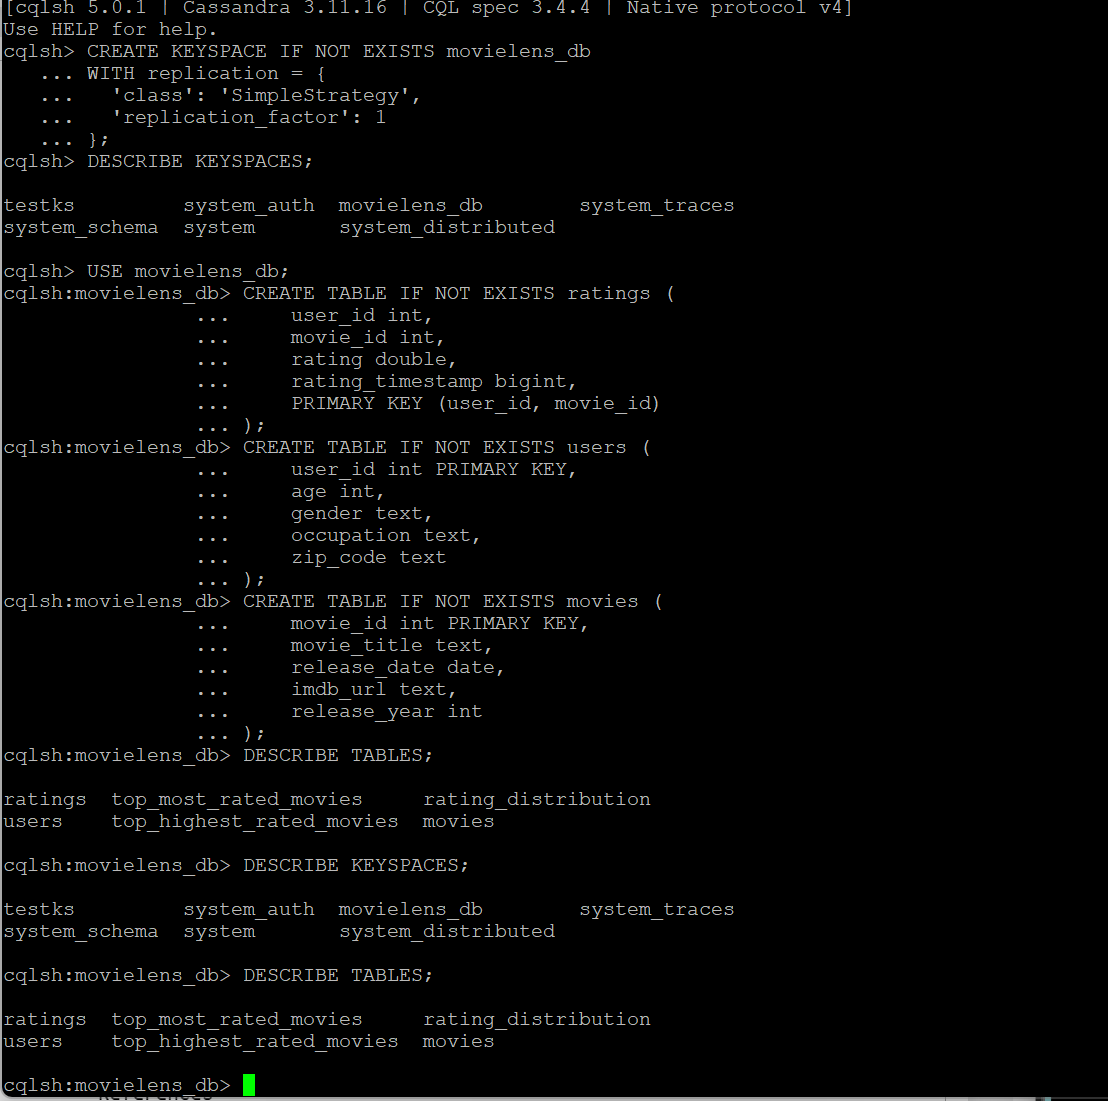

In [117]:
from IPython.display import Image, display

display(Image(filename="/workspace/screenshots/cqlsh_1.png"))

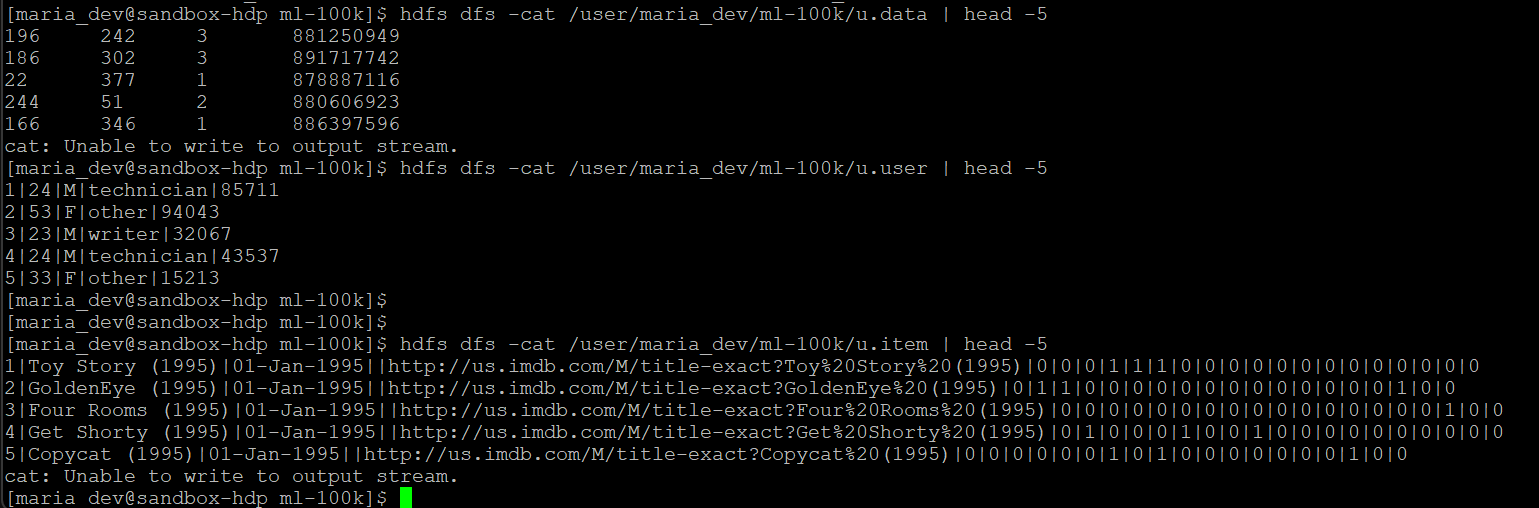

In [119]:
from IPython.display import Image, display

display(Image(filename="/workspace/screenshots/hdfs_2.png"))

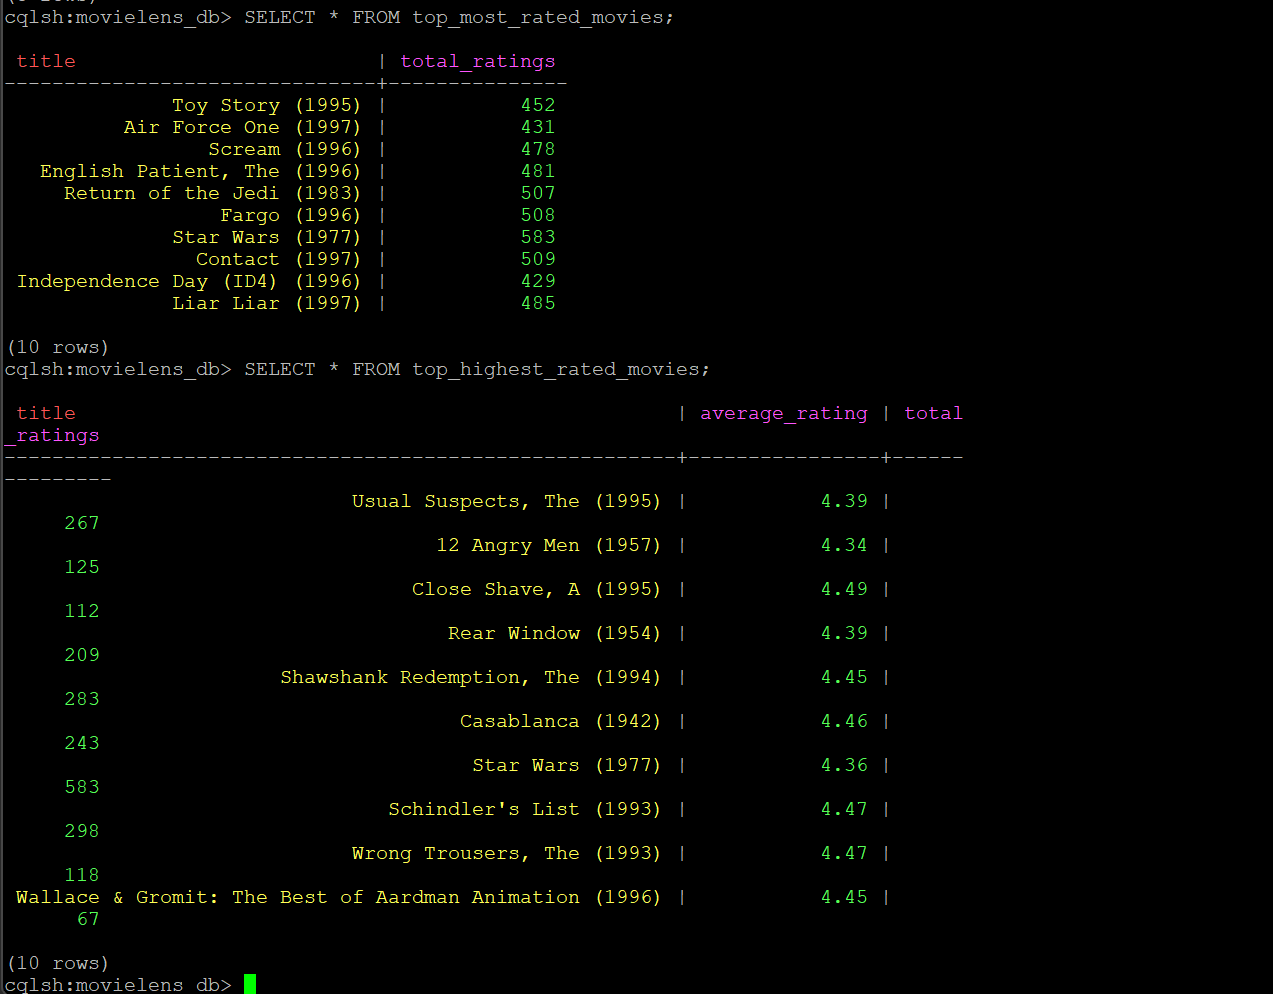

In [120]:
from IPython.display import Image, display

display(Image(filename="/workspace/screenshots/cqlsh_3.png"))

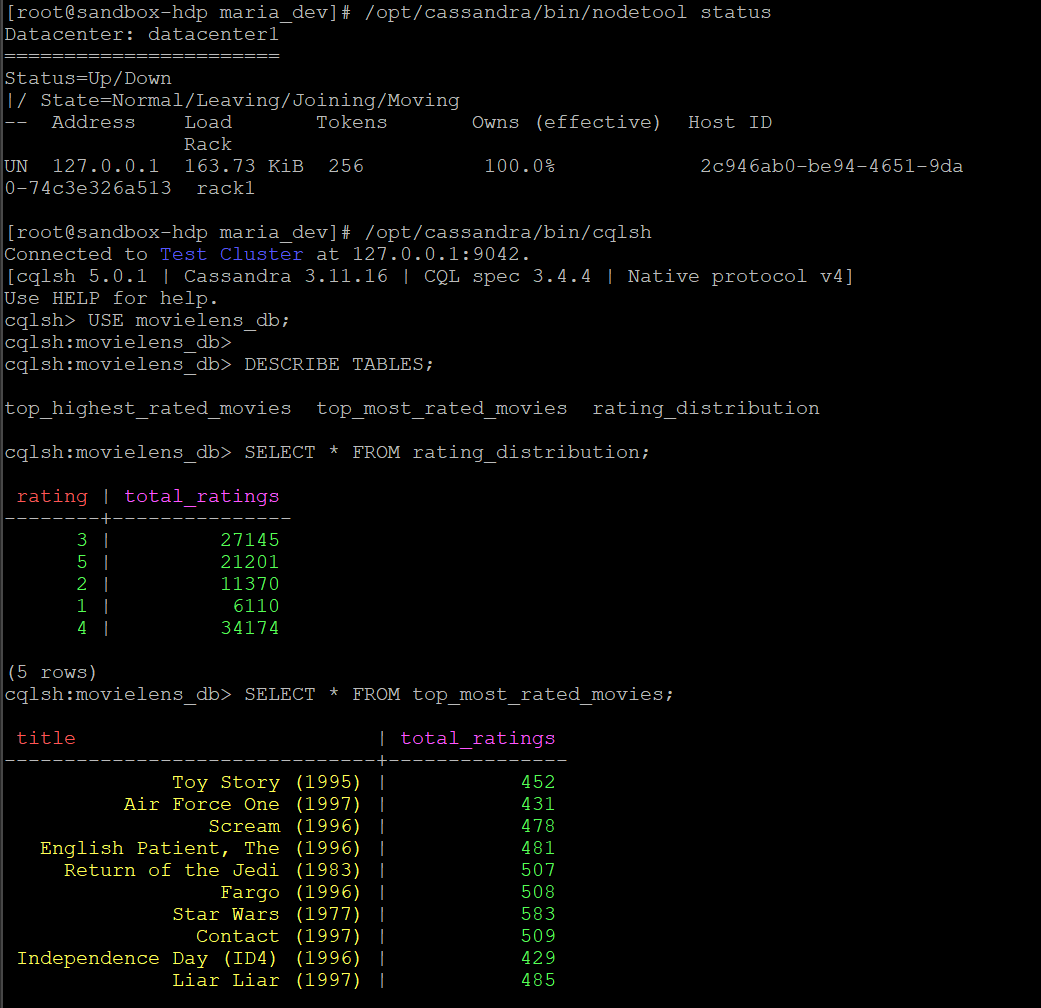

In [121]:
from IPython.display import Image, display

display(Image(filename="/workspace/screenshots/cqlsh_4.png"))

## Step 2: Export your processed DataFrames from Jupyter

In [99]:
# Create export folder
import os

EXPORT_PATH = "/workspace/cassandra_export"
os.makedirs(EXPORT_PATH, exist_ok=True)

print("Export folder created:", EXPORT_PATH)

Export folder created: /workspace/cassandra_export


In [100]:
# Export ratings
ratings_for_cassandra_df = ratings_clean_df.select(
    "user_id",
    "movie_id",
    "rating",
    F.col("timestamp").alias("rating_timestamp")
)

In [101]:
# Export as one CSV file
ratings_for_cassandra_df \
    .coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("/workspace/cassandra_export/ratings")

In [102]:
# Export users
users_for_cassandra_df = users_clean_df.select(
    "user_id",
    "age",
    "gender",
    "occupation",
    "zip_code"
)

In [103]:
users_for_cassandra_df \
    .coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("/workspace/cassandra_export/users")

In [104]:
# Export movies
# Cassandra date compatibility can sometimes be troublesome in older Spark connectors, so export the release date as text first
movies_for_cassandra_df = movies_clean_df.select(
    "movie_id",
    "movie_title",
    F.date_format("release_date", "yyyy-MM-dd").alias("release_date"),
    "imdb_url",
    "release_year"
)


In [105]:
movies_for_cassandra_df \
    .coalesce(1) \
    .write \
    .mode("overwrite") \
    .option("header", True) \
    .csv("/workspace/cassandra_export/movies")

In [106]:
# Check output
import os

for root, dirs, files in os.walk("/workspace/cassandra_export"):
    for file_name in files:
        if file_name.startswith("part-"):
            print(os.path.join(root, file_name))

/workspace/cassandra_export/movies/part-00000-aeef00b8-815f-4297-939a-39b7f375ee36-c000.csv
/workspace/cassandra_export/ratings/part-00000-7f18af6f-05dd-476e-bf1d-ac33356e451b-c000.csv
/workspace/cassandra_export/users/part-00000-c5ef858d-b970-40c3-9e02-ce0dfe70dd83-c000.csv


## Step 3: Give the files names

In [107]:
import glob
import shutil
import os

exports = {
    "ratings": "ratings.csv",
    "users": "users.csv",
    "movies": "movies.csv"
}

for folder, output_name in exports.items():
    matches = glob.glob(
        "/workspace/cassandra_export/{}/part-*".format(folder)
    )

    if not matches:
        print("No part file found for:", folder)
        continue

    destination = os.path.join(
        "/workspace/cassandra_export",
        output_name
    )

    shutil.copy(matches[0], destination)
    print("Created:", destination)

Created: /workspace/cassandra_export/ratings.csv
Created: /workspace/cassandra_export/users.csv
Created: /workspace/cassandra_export/movies.csv


In [108]:
# Verify
print(os.listdir("/workspace/cassandra_export"))

['movies', 'movies.csv', 'ratings', 'ratings.csv', 'users', 'users.csv']


## Step 4: Copy the files from Docker to Windows

mkdir C:\movielens_cassandra

docker cp vigorous_vaughan:/workspace/cassandra_export/ratings.csv C:\movielens_cassandra\ratings.csv

docker cp vigorous_vaughan:/workspace/cassandra_export/users.csv C:\movielens_cassandra\users.csv

docker cp vigorous_vaughan:/workspace/cassandra_export/movies.csv C:\movielens_cassandra\movies.csv

Check :
dir C:\movielens_cassandra

## Step 5: Transfer the files into HDP Sandbox

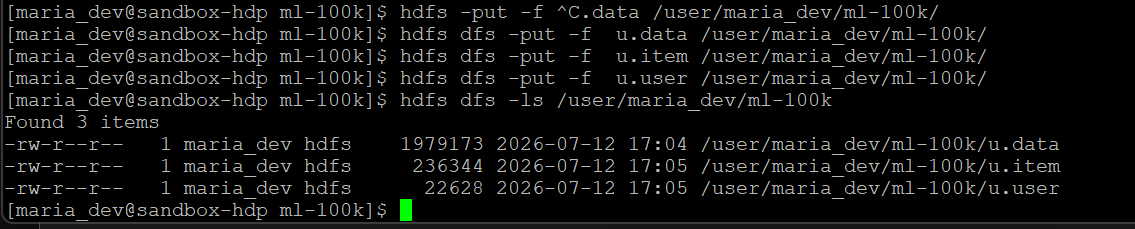

In [122]:
from IPython.display import Image, display

display(Image(filename="/workspace/screenshots/hdfs_1.png"))

## Step 6: Check for the Spark-Cassandra connector

In [110]:
spark.sparkContext.getConf().getAll()

[('spark.driver.port', '34541'),
 ('spark.sql.shuffle.partitions', '4'),
 ('spark.rdd.compress', 'True'),
 ('spark.app.id', 'local-1783936452135'),
 ('spark.serializer.objectStreamReset', '100'),
 ('spark.app.name', 'MovieLens_Data_Management_Assignment'),
 ('spark.master', 'local[*]'),
 ('spark.executor.id', 'driver'),
 ('spark.submit.deployMode', 'client'),
 ('spark.driver.host', '2ba71799d77a'),
 ('spark.pyspark.python', '/usr/bin/python3'),
 ('spark.ui.showConsoleProgress', 'true'),
 ('spark.pyspark.driver.python', '/usr/bin/python3')]

# 10. Data Visualisations

In [89]:
import pandas as pd
print(pd.__version__)

1.1.5


## a) Top Highest Rated Movies

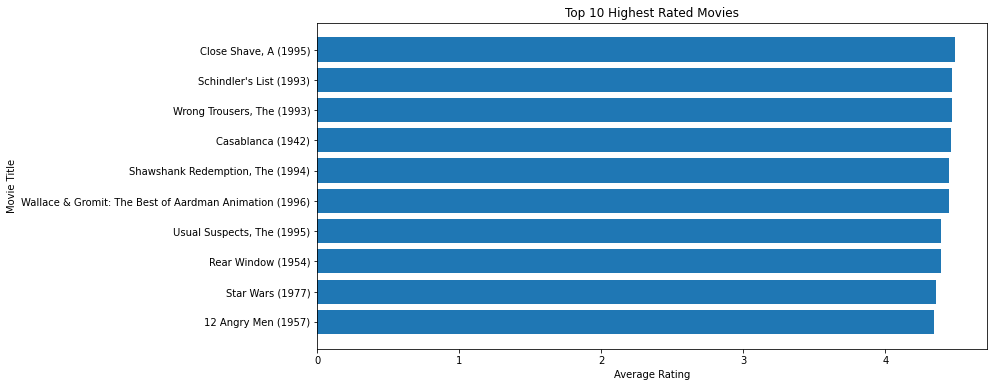

In [90]:
import matplotlib.pyplot as plt
import pandas as pd

top10_pd = top10_movies_df.toPandas()

plt.figure(figsize=(12,6))

plt.barh(
    top10_pd["movie_title"],
    top10_pd["average_rating"]
)

plt.xlabel("Average Rating")
plt.ylabel("Movie Title")
plt.title("Top 10 Highest Rated Movies")

plt.gca().invert_yaxis()

plt.show()

## b) Rating Distribution

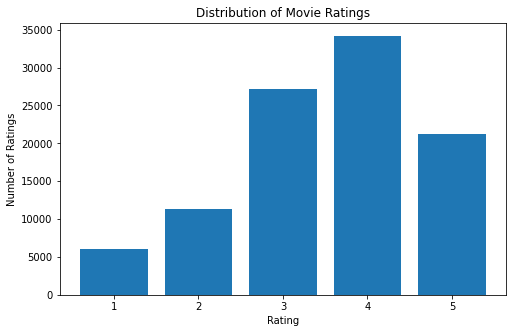

In [91]:
rating_distribution = ratings_df.groupBy("rating").count()

rating_pd = rating_distribution.toPandas()

plt.figure(figsize=(8,5))

plt.bar(
    rating_pd["rating"],
    rating_pd["count"]
)

plt.xlabel("Rating")

plt.ylabel("Number of Ratings")

plt.title("Distribution of Movie Ratings")

plt.show()

## c) Gender Distribution

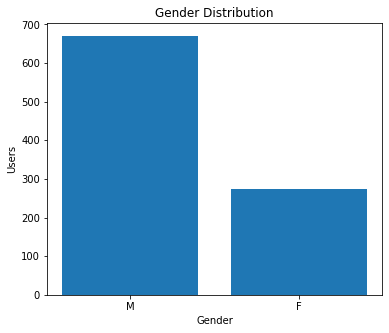

In [92]:
gender_distribution = users_clean_df.groupBy("gender").count()

gender_pd = gender_distribution.toPandas()

plt.figure(figsize=(6,5))

plt.bar(
    gender_pd["gender"],
    gender_pd["count"]
)

plt.xlabel("Gender")

plt.ylabel("Users")

plt.title("Gender Distribution")

plt.show()

## d) Age Group Distribution

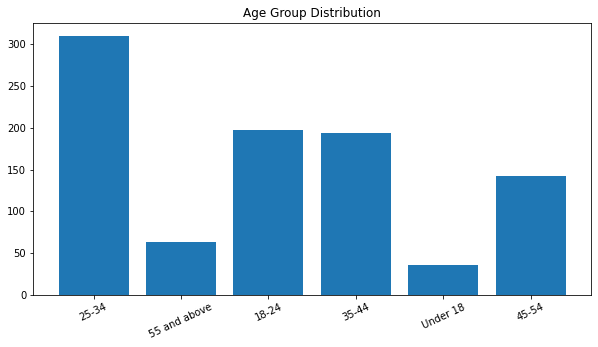

In [93]:
age_distribution = users_clean_df.groupBy("age_group").count()

age_pd = age_distribution.toPandas()

plt.figure(figsize=(10,5))

plt.bar(
    age_pd["age_group"],
    age_pd["count"]
)

plt.xticks(rotation=25)

plt.title("Age Group Distribution")

plt.show()

## e) Occupation Distribution

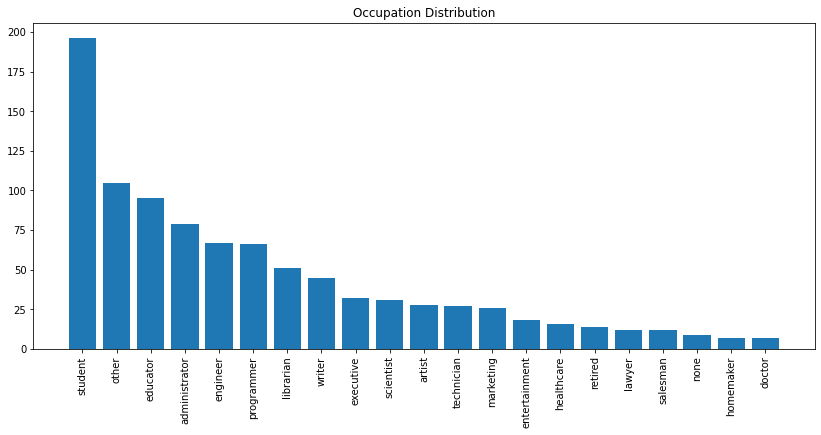

In [94]:
occupation_distribution = users_clean_df.groupBy("occupation").count()

occupation_pd = occupation_distribution.toPandas()

occupation_pd = occupation_pd.sort_values(
    "count",
    ascending=False
)

plt.figure(figsize=(14,6))

plt.bar(
    occupation_pd["occupation"],
    occupation_pd["count"]
)

plt.xticks(rotation=90)

plt.title("Occupation Distribution")

plt.show()

## f) Movie Released by Year

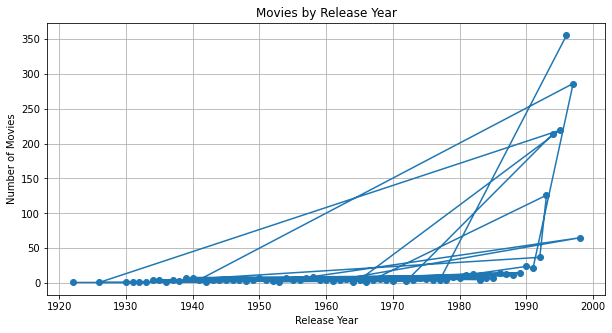

In [95]:
release_distribution = movies_clean_df.groupBy(
    "release_year"
).count()

release_pd = release_distribution.toPandas()

plt.figure(figsize=(10,5))

plt.plot(
    release_pd["release_year"],
    release_pd["count"],
    marker="o"
)

plt.xlabel("Release Year")

plt.ylabel("Number of Movies")

plt.title("Movies by Release Year")

plt.grid(True)

plt.show()

## g) Favourite Genres (Qiii)

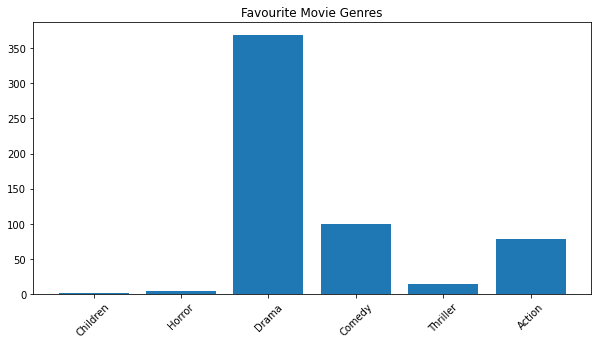

In [96]:
genre_distribution = favourite_genre_df.groupBy(
    "favourite_genre"
).count()

genre_pd = genre_distribution.toPandas()

plt.figure(figsize=(10,5))

plt.bar(
    genre_pd["favourite_genre"],
    genre_pd["count"]
)

plt.xticks(rotation=45)

plt.title("Favourite Movie Genres")

plt.show()

# 11. Discussion
The MovieLens 100K dataset was successfully analysed using Apache Spark and Spark SQL. The integration of the ratings, movie information and user demographic datasets enabled comprehensive analysis of user preferences and movie popularity.

The analysis showed that several movies consistently achieved high average ratings based on a sufficient number of user reviews, indicating broad user satisfaction. The demographic analysis also revealed differences in age groups, occupations and gender distributions among MovieLens users.

Users who rated at least fifty movies demonstrated clear genre preferences, providing valuable insights into viewing behaviour. These findings illustrate how Spark SQL can efficiently process large datasets and support analytical decision-making.

Overall, Apache Spark significantly reduced the complexity of analysing large datasets through distributed processing, while Cassandra provides scalable storage for processed analytical data.

# 12. Conclusion

This assignment successfully demonstrated the integration of Apache Spark and Apache Cassandra for analysing the MovieLens 100K dataset.

The dataset was loaded, parsed and transformed into Spark DataFrames before undergoing data cleaning and preprocessing. Analytical queries were executed using Spark SQL to identify movie ratings, highly rated movies, favourite genres and specific user demographics.

The processed datasets were prepared for storage in Apache Cassandra, providing scalable and fault-tolerant storage suitable for Big Data applications.

Overall, the project demonstrates how modern Big Data technologies can efficiently process large datasets and support data-driven decision making through distributed computing and NoSQL database technologies.

# 13. References
Apache Cassandra. (2024). Apache Cassandra Documentation.
https://cassandra.apache.org/doc/latest/

Apache Spark. (2024). Apache Spark Documentation.
https://spark.apache.org/docs/latest/

GroupLens Research. (1998). MovieLens 100K Dataset.
https://grouplens.org/datasets/movielens/

White, T. (2015). Hadoop: The Definitive Guide (4th ed.). O'Reilly Media.

Karau, H., Konwinski, A., Wendell, P., & Zaharia, M. (2015). Learning Spark. O'Reilly Media.

In [97]:
import os
os.getcwd()

'/workspace'